# Introduction to Pipelines

First half of this notebook is copied from pyearthtools and used to try and get a basic understanding of datapipelines in pyearthtools.

Second half of this notebook is to explore more about ERA5 data.

In [9]:
# Here we'll use WeatherBench 2 ERA5 dataset as data source
from pyearthtools.data.download.weatherbench import WB2ERA5

In [10]:
# Now we import the pipeline model which is new in this example
import pyearthtools.pipeline

# and the operations module used as steps of the pipeline
import pyearthtools.pipeline.operations as ops

import pyearthtools.data.transforms.coordinates as coords

## Data source

For this example, we are using the [ERA5 datasets from WeatherBench 2](https://weatherbench2.readthedocs.io/en/latest/data-guide.html#era5), at a low resolution.
Data is small and direclty fetched from public Google Cloud bucket.

We can first have a look at the full dataset to see which variables and levels we want to assemble in the pipeline.

In [11]:
WB2ERA5(resolution="64x32").dataset

Make sure to check the LICENSE for this WB2ERA5 dataset. Some WeatherBench2 datasets allow commercial use. Others only permit research use. The license text can be accessed via the `.license()` method.


<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * longitude                                         (longitude) float64 512B ...
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(1200, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(16300, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(1200, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(1200, 13, 64, 32), meta=np.ndarray>

## Create a data preparation pipeline. 

We can use pipelines to create a reproducable and explainable process to prepare data for specific tasks. 
Pipelines could also be shared as templates to complete similar work. 

The pipeline below:
1. Selects the 'u' and 'v' wind variables at 500 and 850 hPa, as well as 2 meter temperature.
2. Selects the 'geopotential' and 'vorticity' atmospheric variables at 850 hPa. 
3. Merges these into a single dataset. 
4. Sorts the variables into a specified order.
5. Applies a coordinate transformation to ensure latitude is formated as 0-360 degrees (not -180-180 degrees) using the `StandardLongitude` class.
6. Reverses the data by 'level' coordinate using the `ReIndex` class. 

In [12]:
data_preparation = pyearthtools.pipeline.Pipeline(
    (
        WB2ERA5(resolution="64x32", variables=["u", "v", "t2m"], level=[500, 850]),
        WB2ERA5(resolution="64x32", variables=["geopotential", "vorticity"], level=850),
    ),
    ops.xarray.Merge(),
    ops.xarray.Sort(
        [
            "u_component_of_wind",
            "v_component_of_wind",
            "2m_temperature",
            "geopotential",
            "vorticity",
        ]
    ),
    ops.Transforms(
        apply=coords.StandardLongitude(type="0-360") + coords.ReIndex(level="reversed")
    ),
    # These methods will be explained when we create a pipeline for machine learning.
    # ops.xarray.reshape.CoordinateFlatten('level'),
    # ops.xarray.conversion.ToNumpy(),
    # ops.numpy.reshape.Squeeze(1),
)

Make sure to check the LICENSE for this WB2ERA5 dataset. Some WeatherBench2 datasets allow commercial use. Others only permit research use. The license text can be accessed via the `.license()` method.
Make sure to check the LICENSE for this WB2ERA5 dataset. Some WeatherBench2 datasets allow commercial use. Others only permit research use. The license text can be accessed via the `.license()` method.


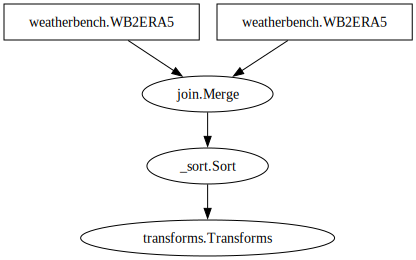

In [13]:
# Inspect the data_preparation pipeline which also visualises the pipeline as a graph.
data_preparation

In [14]:
# Use the pipeline to create a sample for a specific date.
sample = data_preparation["20120102T00"]
sample

<xarray.Dataset> Size: 58kB
Dimensions:              (latitude: 32, level: 2, longitude: 64, time: 1)
Coordinates:
  * latitude             (latitude) float64 256B -87.19 -81.56 ... 81.56 87.19
  * level                (level) int64 16B 850 500
  * longitude            (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * time                 (time) datetime64[ns] 8B 2012-01-02
Data variables:
    u_component_of_wind  (time, level, longitude, latitude) float32 16kB dask.array<chunksize=(1, 2, 64, 32), meta=np.ndarray>
    v_component_of_wind  (time, level, longitude, latitude) float32 16kB dask.array<chunksize=(1, 2, 64, 32), meta=np.ndarray>
    2m_temperature       (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    geopotential         (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    vorticity            (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>

In [15]:
# Inspect vorticity DataArray variable.
sample.vorticity

<xarray.DataArray 'vorticity' (time: 1, longitude: 64, latitude: 32)> Size: 8kB
dask.array<getitem, shape=(1, 64, 32), dtype=float32, chunksize=(1, 64, 32), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 2012-01-02
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19

## Exploring structure of sample data

In [19]:
print("dims:", sample.dims)
print("coords:", list(sample.coords))
print("data vars:", list(sample.data_vars))
print("time:", sample.time.values)
if "level" in sample.dims:
    print("levels:", sample.level.values)
print("longitude range:", sample.longitude.values[:3], "...", sample.longitude.values[-3:])
print("latitude range:", sample.latitude.values[:3], "...", sample.latitude.values[-3:])

dims: FrozenMappingWarningOnValuesAccess({'latitude': 32, 'level': 2, 'longitude': 64, 'time': 1})
coords: ['latitude', 'level', 'longitude', 'time']
data vars: ['u_component_of_wind', 'v_component_of_wind', '2m_temperature', 'geopotential', 'vorticity']
time: ['2012-01-02T00:00:00.000000000']
levels: [850 500]
longitude range: [ 0.     5.625 11.25 ] ... [343.125 348.75  354.375]
latitude range: [-87.1875 -81.5625 -75.9375] ... [75.9375 81.5625 87.1875]


In [20]:
for name, da in sample.data_vars.items():
    print(f"=== {name} ===")
    print(" shape:", da.shape)
    print(" dtype:", da.dtype)
    print(" coords:", list(da.coords))
    print(" min:", float(da.min()))
    print(" max:", float(da.max()))
    print(" mean:", float(da.mean()))
    if da.isnull().any():
        print(" nans:", int(da.isnull().sum()))
    else:
        print(" nans: 0")
    print()

=== u_component_of_wind ===
 shape: (1, 2, 64, 32)
 dtype: float32
 coords: ['latitude', 'level', 'longitude', 'time']
 min: -17.97298240661621
 max: 55.103248596191406
 mean: 4.648500919342041
 nans: 0

=== v_component_of_wind ===
 shape: (1, 2, 64, 32)
 dtype: float32
 coords: ['latitude', 'level', 'longitude', 'time']
 min: -35.666709899902344
 max: 37.86798095703125
 mean: -0.11624625325202942
 nans: 0

=== 2m_temperature ===
 shape: (1, 64, 32)
 dtype: float32
 coords: ['latitude', 'longitude', 'time']
 min: 227.48916625976562
 max: 308.49945068359375
 mean: 277.1636047363281
 nans: 0

=== geopotential ===
 shape: (1, 64, 32)
 dtype: float32
 coords: ['latitude', 'longitude', 'time']
 min: 9729.80859375
 max: 16073.9033203125
 mean: 13660.869140625
 nans: 0

=== vorticity ===
 shape: (1, 64, 32)
 dtype: float32
 coords: ['latitude', 'longitude', 'time']
 min: -0.00010372047836426646
 max: 0.00021233249572105706
 mean: -1.0639143965818221e-07
 nans: 0



ValueError: too many values to unpack (expected 2)

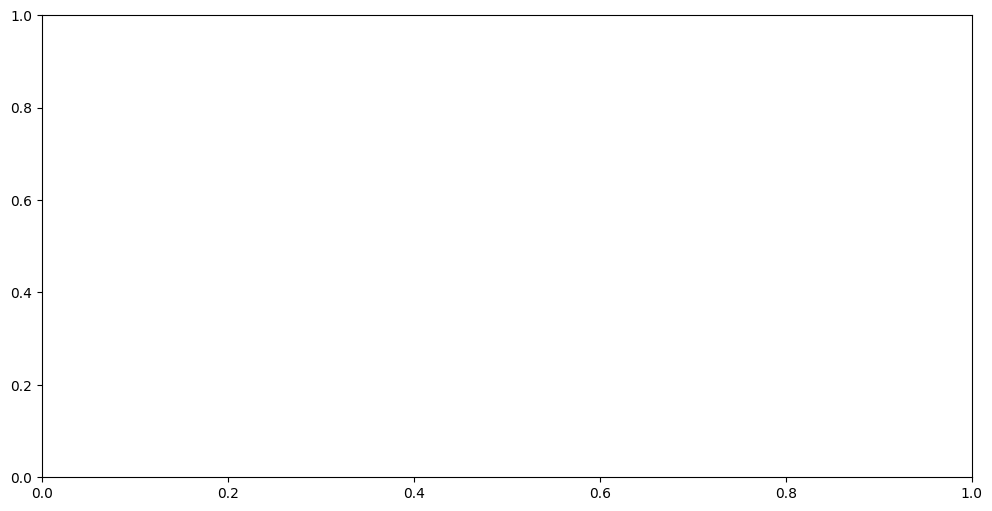

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

u_name = "u_component_of_wind"
v_name = "v_component_of_wind"

if u_name in sample.data_vars and v_name in sample.data_vars:
    u = sample[u_name]
    v = sample[v_name]
    if "level" in u.dims:
        u_plot = u.sel(level=850)
        v_plot = v.sel(level=850)
        level_label = "850 hPa"
    else:
        u_plot = u
        v_plot = v
        level_label = "surface"

    if "time" in u_plot.dims:
        u_plot = u_plot.isel(time=0)
    if "time" in v_plot.dims:
        v_plot = v_plot.isel(time=0)

    lon = u_plot.longitude.values
    lat = u_plot.latitude.values
    U = np.squeeze(u_plot.values)
    V = np.squeeze(v_plot.values)

    step = max(1, min(len(lat) // 20, len(lon) // 20))
    X, Y = np.meshgrid(lon[::step], lat[::step])
    Uq = U[::step, ::step]
    Vq = V[::step, ::step]

    plt.figure(figsize=(12, 6))
    plt.quiver(X, Y, Uq, Vq, scale=700, width=0.0025, pivot="mid")
    plt.title(f"Wind vector field ({level_label})")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
else:
    print(f"Missing wind variables in sample: {u_name}, {v_name}")